In [ ]:
# Install required packages
!pip install anthropic  # For Claude API
!pip install scikit-learn
!pip install pandas numpy
!pip install transformers torch
# Clone FakeNewsNet repository
!git clone https://github.com/KaiDMML/FakeNewsNet.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.2/325.2 kB 11.5 MB/s eta 0:00:00
Cloning into 'FakeNewsNet'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 759 (delta 8), reused 2 (delta 2), pack-reused 747 (from 3)
Receiving objects: 100% (759/759), 43.99 MiB | 20.67 MiB/s, done.
Resolving deltas: 100% (155/155), done.


Alternate way

In [ ]:
# Installs
!pip -q install --upgrade pip
!pip -q install "anthropic>=0.34" "pandas>=2.0" "numpy>=1.24" "scikit-learn>=1.3" "transformers>=4.40" "torch>=2.2"

# Claude API key (make sure you set it in the notebook's env first)
import os
#assert "ANTHROPIC_API_KEY" in os.environ, "Set ANTHROPIC_API_KEY in the env (Runtime > Runtime env)."
# os.environ["ANTHROPIC_API_KEY"] = "sk-ant-api03-xx"

# Get or update the repo
import subprocess
repo_url = "https://github.com/KaiDMML/FakeNewsNet.git"
repo_dir = "/content/FakeNewsNet"
if not os.path.exists(repo_dir):
    !git clone $repo_url
else:
    !git -C $repo_dir pull

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.7 MB/s eta 0:00:00
Cloning into 'FakeNewsNet'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 759 (delta 8), reused 2 (delta 2), pack-reused 747 (from 3)
Receiving objects: 100% (759/759), 43.99 MiB | 24.40 MiB/s, done.
Resolving deltas: 100% (155/155), done.


In [ ]:
from anthropic import Anthropic
from typing import List, Dict
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import json
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
def load_fakenewsnet_data(base_path='FakeNewsNet/dataset'):
    """
    Load articles from FakeNewsNet CSV files
    """
    all_data = []
    csv_files = [
        ('politifact_fake.csv', 'politifact', 1),  # fake = 1
        ('politifact_real.csv', 'politifact', 0),  # real = 0
        ('gossipcop_fake.csv', 'gossipcop', 1),
        ('gossipcop_real.csv', 'gossipcop', 0)
    ]

    base_path = Path(base_path)

    for filename, source, label in csv_files:
        file_path = base_path / filename

        if file_path.exists():
            print(f"Loading {filename}...")
            try:
                # Loading the CSV file
                df_temp = pd.read_csv(file_path)

                # Addding source and label columns
                df_temp['source'] = source
                df_temp['label'] = label
                print(f"  - Loaded {len(df_temp)} articles from {filename}")
                print(f"  - Columns: {df_temp.columns.tolist()}")

                all_data.append(df_temp)
            except Exception as e:
                print(f"  - Error loading {filename}: {e}")
        else:
            print(f"  - File not found: {file_path}")

    if all_data:
        # Combining all dataframes
        df = pd.concat(all_data, ignore_index=True)
        print(f"\nCombined dataset columns: {df.columns.tolist()}")
        column_mappings = {
            'news_url': 'url',
            'URL': 'url',
            'Title': 'title',
            'tweet_ids': 'tweet_ids',
            'Text': 'text',
            'text': 'text',
            'title': 'title'
        }

        # Renaming columns to standard names
        df = df.rename(columns=column_mappings)
        if 'id' not in df.columns:
            df['id'] = df.index.astype(str)
        if 'text' not in df.columns and 'title' in df.columns:
            print("\nNote: No 'text' column found, using 'title' for text analysis")
            df['text'] = df['title']

        return df
    else:
        print("No data files were loaded successfully")
        return pd.DataFrame()

def create_balanced_sample(df, sample_size_per_class=250, random_state=42):
    """
    Create a balanced dataset with equal numbers of fake and real articles

    Parameters:
    - df: Original dataframe
    - sample_size_per_class: Number of samples for each class (fake/real)
    - random_state: Random seed for reproducibility

    Returns:
    - Balanced dataframe
    """
    # Counting available samples
    n_fake = (df['label'] == 1).sum()
    n_real = (df['label'] == 0).sum()

    print(f"\nOriginal dataset distribution:")
    print(f"  - Fake articles: {n_fake}")
    print(f"  - Real articles: {n_real}")

    # Adjusting sample size if not enough samples
    max_sample_size = min(n_fake, n_real, sample_size_per_class)

    if max_sample_size < sample_size_per_class:
        print(f"\n Requested {sample_size_per_class} samples per class, but only {max_sample_size} available")
        print(f"   Using {max_sample_size} samples per class instead")

    # Sample equal numbers of fake and real articles
    fake_articles = df[df['label'] == 1].sample(n=max_sample_size, random_state=random_state)
    real_articles = df[df['label'] == 0].sample(n=max_sample_size, random_state=random_state)

    # Combining and shuffling
    df_balanced = pd.concat([fake_articles, real_articles])
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    print(f"\nBalanced dataset created:")
    print(f"  - Total samples: {len(df_balanced)}")
    print(f"  - Fake articles: {(df_balanced['label'] == 1).sum()} ({(df_balanced['label'] == 1).mean()*100:.1f}%)")
    print(f"  - Real articles: {(df_balanced['label'] == 0).sum()} ({(df_balanced['label'] == 0).mean()*100:.1f}%)")

    print(f"\nDistribution by source in balanced dataset:")
    for source in df_balanced['source'].unique():
        source_df = df_balanced[df_balanced['source'] == source]
        print(f"  {source}:")
        print(f"    - Fake: {(source_df['label'] == 1).sum()}")
        print(f"    - Real: {(source_df['label'] == 0).sum()}")

    return df_balanced

In [ ]:
import re
def initialize_claude_client(api_key: str):
    try:
        client = Anthropic(api_key=api_key)
        _ = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=8,
            messages=[{"role": "user", "content": "ping"}]
        )
        print("Claude API client initialized successfully!")
        return client
    except ImportError:
        print("Anthropic library not installed. Run: pip install anthropic")
        return None
    except Exception as e:
        print(f"Error initializing Claude client: {e}")
        return None
def create_prompt(article_title, article_text, max_length=800):
    title = "" if pd.isna(article_title) or article_title is None else str(article_title)
    text  = "" if pd.isna(article_text)  or article_text  is None else str(article_text)

    if not text.strip() and title.strip():
        text = title
    if not text.strip() and not title.strip():
        title, text = "No title", "No content available"

    if len(text) > max_length:
        text = text[:max_length] + "..."

    return f"""Analyze this news headline/article and provide integer scores (0–10) for each characteristic:

Title: {title}
Content: {text}

Return ONLY a JSON object with integer scores from 0–10:
{{
  "sensationalism": 7,
  "emotional_language": 5,
  "factual_claims": 6,
  "source_credibility": 4,
  "logical_consistency": 7,
  "clickbait_level": 8,
  "bias_level": 5,
  "professional_tone": 3
}}"""
FEAT_KEYS = [
    "sensationalism","emotional_language","factual_claims","source_credibility",
    "logical_consistency","clickbait_level","bias_level","professional_tone"
]

def _anthropic_text(message):
    parts = []
    for blk in getattr(message, "content", []) or []:
        if getattr(blk, "type", None) == "text":
            parts.append(blk.text)
    return "\n".join(parts).strip()

def _strip_code_fences(txt: str) -> str:
    low = txt.lower()
    if "```json" in low:
        return txt.split("```json")[-1].split("```")[0]
    if "```" in low:
        return txt.split("```")[1]
    return txt

def _coerce_scores(d, default=5):
    out = {}
    for k in FEAT_KEYS:
        v = d.get(k, default)
        try:
            v = int(round(float(v)))
        except Exception:
            v = default
        out[k] = int(np.clip(v, 0, 10))
    return out

def extract_llm_features_claude(articles_df: pd.DataFrame, api_key: str,
                                model="claude-3-haiku-20240307",
                                retries=2, pace=0.25) -> pd.DataFrame:
    client = Anthropic(api_key=api_key)
    feats = []
    ok = err = 0

    print(f"Processing {len(articles_df)} articles with {model}…")
    for idx, row in articles_df.iterrows():
        title = row.get("title", "")
        text  = row.get("text",  title)

        prompt = create_prompt(title, text)

        last_exc = None
        for attempt in range(retries + 1):
            try:
                msg = client.messages.create(
                    model=model,
                    max_tokens=200,
                    temperature=0,
                    messages=[{"role": "user", "content": prompt}]
                )
                resp = _anthropic_text(msg)
                resp = _strip_code_fences(resp)
                start, end = resp.find("{"), resp.rfind("}")
                if start == -1 or end == -1:
                    raise ValueError("No JSON object in response")
                data = json.loads(resp[start:end+1])
                feats.append(_coerce_scores(data))
                ok += 1
                break
            except Exception as e:
                last_exc = e
                if "rate" in str(e).lower():
                    time.sleep(60)
                elif attempt < retries:
                    time.sleep(1.0 * (attempt + 1))
                else:
                    err += 1
                    feats.append(_coerce_scores({}))  # defaults
        if (ok + err) % 20 == 0:
            print(f"Progress: {(ok+err)}/{len(articles_df)} (✓{ok} ✗{err})")
        time.sleep(pace)

    print(f"\nFeature extraction complete: ✓{ok}, ✗{err}")
    out = pd.DataFrame(feats, index=articles_df.index)
    out = out.astype({k: "int64" for k in FEAT_KEYS})
    return out
_WORD = re.compile(r"\b[\w']+\b", re.UNICODE)

def _count_words(text, vocab):
    tokens = [t.lower() for t in _WORD.findall(text or "")]
    s = set(tokens)
    return sum(1 for w in vocab if w in s)

def extract_rule_based_features(articles_df: pd.DataFrame) -> pd.DataFrame:
    feats = []
    sensational_terms = {"shocking","unbelievable","explosive","breaking"}
    emotional_terms    = {"angry","furious","devastated","amazing","horrible"}
    absolutist_terms   = {"always","never","all","none","every"}
    clickbait_bigrams  = {"won't believe","must see","what happens next"}

    for _, row in articles_df.iterrows():
        title = str(row.get("title","") or "")
        text  = str(row.get("text", title) or "")

        # token-aware counts
        sens = min(10, title.count("!")*2 + 5*_count_words(title, sensational_terms))
        emo  = min(10, 2*_count_words(text, emotional_terms))
        facts = max(0, 10 - 2*title.count("?"))
        cred  = 5 + (2 if "according to" in text.lower() else -2)
        cred  = int(np.clip(cred, 0, 10))
        logic = 6  # fixed mid value to be deterministic
        click = min(10, 3*title.lower().count("you") +
                         5*sum(1 for b in clickbait_bigrams if b in title.lower()) +
                         (3 if "?" in title else 0))
        bias  = min(10, 2*_count_words(text, absolutist_terms))
        prof  = max(0, 10 - 2*title.count("!") - 3*title.count("..."))

        feats.append({
            "sensationalism": sens,
            "emotional_language": emo,
            "factual_claims": facts,
            "source_credibility": cred,
            "logical_consistency": logic,
            "clickbait_level": click,
            "bias_level": bias,
            "professional_tone": prof
        })

    out = pd.DataFrame(feats, index=articles_df.index)
    return out.astype({k: "int64" for k in FEAT_KEYS})

In [ ]:
def train_and_evaluate_model(features_df, labels, *,
                             sparse=False,
                             scale=True,
                             class_weight=None,
                             solver=None,
                             random_state=42):
    """
    Train and evaluate a logistic regression model.

    Parameters
    ----------
    features_df : pd.DataFrame or scipy sparse matrix
        Feature matrix (rows aligned with `labels`). If DataFrame, column names are used for coefficient table.
    labels : array-like
        Binary labels (e.g., Fake=1, Real=0).
    sparse : bool
    scale : bool
    class_weight : None or "balanced" or dict
    solver : str or None
    random_state : int

    Returns
    -------
    model, scaler, metrics_dict
    """
    if isinstance(features_df, pd.DataFrame):
        X = features_df.copy()
        feature_names = X.columns.to_list()
    else:
        X = features_df
        feature_names = getattr(features_df, "columns", None) or [f"f{i}" for i in range(X.shape[1])]

    y = np.asarray(labels)
    if y.shape[0] != (X.shape[0] if hasattr(X, "shape") else len(X)):
        raise ValueError("features_df and labels must have the same number of rows.")

    if (isinstance(X, pd.DataFrame) and len(X) < 10) or (not isinstance(X, pd.DataFrame) and X.shape[0] < 10):
        print("Not enough samples for training. Need at least 10.")
        return None, None, {}

    if isinstance(X, pd.DataFrame):
        before = len(X)
        X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
        y = y[X.index]
        if len(X) < before:
            print(f"Dropped {before - len(X)} rows with NaN/Inf.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = None
    if scale:
        if sparse:
            scaler = MaxAbsScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)
        else:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

    if solver is None:
        solver = "liblinear" if sparse else "lbfgs"

    log_reg = LogisticRegression(
        random_state=random_state,
        max_iter=1000,
        class_weight=class_weight,
        solver=solver,
        n_jobs=None if solver == "liblinear" else -1
    )
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    if hasattr(log_reg, "predict_proba"):
        y_proba = log_reg.predict_proba(X_test)[:, 1]
    else:
        z = log_reg.decision_function(X_test)
        y_proba = 1 / (1 + np.exp(-z))

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    print("Model Performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    if not np.isnan(auc):
        print(f"ROC AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake'], zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Real', 'Pred Fake'],
                yticklabels=['Actual Real', 'Actual Fake'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()

    if hasattr(log_reg, "coef_") and log_reg.coef_.ndim == 2 and log_reg.coef_.shape[0] == 1:
        coefs = log_reg.coef_[0]
        coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
        coef_df["abs_coef"] = coef_df["coefficient"].abs()
        coef_df = coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
        print("\nTop Feature Importances:")
        print(coef_df.head(10))
    else:
        coef_df = None

    metrics = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}
    return log_reg, scaler, metrics

Logistic Regression Baseline (on LLM/Rule Features Only)

Goal: Test how well a simple linear classifier performs using only the 8 numeric features (either from Claude API or rule-based heuristics).

Flow:

**Feature extraction**

Each article is converted into 8 integer scores (0–10):

* sensationalism

* emotional_language

* factual_claims

* source_credibility

* logical_consistency

* clickbait_level

* bias_level

* professional_tone

**Preprocessing**

* Stack features into a dense numeric matrix.

* Standardize with StandardScaler (zero-mean, unit variance) to make coefficients comparable.

**Model training**

* Train a logistic regression classifier
* Split: 80% training / 20% test, stratified by class.

**Evaluation**

* Metrics: Accuracy, Precision, Recall, F1, ROC AUC.

* Outputs a classification report and confusion matrix.

In [ ]:
def train_and_evaluate_model(features_df, labels):
    """
    Train and evaluate logistic regression model
    """
    if len(features_df) < 10:
        print("Not enough samples for training. Need at least 10.")
        return None, None

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        features_df, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train logistic regression
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = log_reg.predict(X_test_scaled)
    y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

    # Evaluate the model
    print("Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features_df.columns,
        'coefficient': log_reg.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)

    print("\nTop Feature Importances:")
    print(feature_importance.head(10))

    return log_reg, scaler

In [ ]:
def run_complete_pipeline(api_key=None, df_input=None, sample_size=50, use_rule_based=False, use_balanced=True):
    print("="*50)
    print("STARTING FAKE NEWS DETECTION PIPELINE")
    print("="*50)

    # 1) Load / prepare data
    if df_input is not None:
        print("\n1. Using provided dataset...")
        df = df_input.copy()
    else:
        print("\n1. Loading data from CSV files...")
        df = load_fakenewsnet_data()
        if len(df) == 0:
            print(" No data loaded. Check data path.")
            return None, None, None
        if use_balanced:
            print("\n1b. Creating balanced dataset...")
            n_fake = (df['label'] == 1).sum()
            n_real = (df['label'] == 0).sum()
            samples_per_class = min(sample_size // 2, n_fake, n_real)
            df = create_balanced_sample(df, sample_size_per_class=samples_per_class, random_state=42)

    # 2) Sample
    if len(df) <= sample_size:
        print(f"\n2. Using all {len(df)} articles...")
        df_sample = df.copy()
    else:
        print(f"\n2. Sampling {sample_size} of {len(df)}…")
        df_sample = df.sample(n=sample_size, random_state=42).copy()

    # 3) Features
    print("\n3. Extracting features...")
    if use_rule_based or api_key is None:
        llm_features = extract_rule_based_features(df_sample)  # must return numeric DataFrame, index aligned
        sparse = False
    else:
        llm_features = extract_llm_features_claude(df_sample, api_key)  # numeric DataFrame, same index
        sparse = False

    llm_features = llm_features.reindex(df_sample.index)
    mask = ~llm_features.isnull().any(axis=1)
    llm_features = llm_features[mask]
    labels = df_sample.loc[llm_features.index, 'label'].values

    # Check sizes and classes
    if len(labels) < 10:
        print(f" Only {len(labels)} usable samples after alignment. Need at least 10.")
        return None, None, None
    if np.unique(labels).size < 2:
        print(" Only one class present after alignment. Cannot train.")
        return None, None, None

    print("\n4. Training logistic regression…")
    model, scaler = train_and_evaluate_model(llm_features, labels)
    metrics = None

    if model is not None:
        print("\n" + "="*50)
        print("PIPELINE COMPLETED SUCCESSFULLY!")
        print("="*50)
        print("\nPipeline Summary:")
        print(f"- Data source: {'Provided' if df_input is not None else 'Loaded from files'}")
        print(f"- Balancing: {'Applied' if use_balanced or df_input is not None else 'Not applied'}")
        print(f"- Feature extraction: {'Rule-based' if use_rule_based or api_key is None else 'Claude API'}")
        print(f"- Articles processed: {len(df_sample)}")
        print(f"- Final model trained on: {len(labels)} samples")

    return model, scaler, llm_features

Loading politifact_fake.csv...
  - Loaded 432 articles from politifact_fake.csv
  - Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']
Loading politifact_real.csv...
  - Loaded 624 articles from politifact_real.csv
  - Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']
Loading gossipcop_fake.csv...
  - Loaded 5323 articles from gossipcop_fake.csv
  - Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']
Loading gossipcop_real.csv...
  - Loaded 16817 articles from gossipcop_real.csv
  - Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']

Combined dataset columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']

Note: No 'text' column found, using 'title' for text analysis

Original dataset distribution:
  - Fake articles: 5755
  - Real articles: 17441

Balanced dataset created:
  - Total samples: 500
  - Fake articles: 250 (50.0%)
  - Real articles: 250 (50.0%)

Distribution by source in balanced dataset:
 

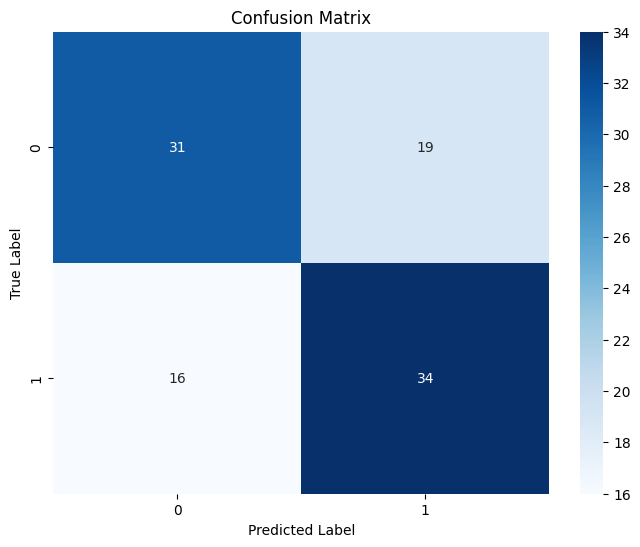


Top Feature Importances:
               feature  coefficient
6           bias_level     0.496774
3   source_credibility    -0.421088
5      clickbait_level    -0.302329
2       factual_claims    -0.283217
1   emotional_language    -0.279058
0       sensationalism     0.112187
7    professional_tone     0.067132
4  logical_consistency     0.033638

PIPELINE COMPLETED SUCCESSFULLY!

Pipeline Summary:
- Data source: Provided
- Balancing: Applied
- Feature extraction: Claude API
- Articles processed: 500
- Final model trained on: 500 samples


In [ ]:
API_KEY = os.environ.get("ANTHROPIC_API_KEY")
df = load_fakenewsnet_data()
df_balanced = create_balanced_sample(df, sample_size_per_class=250)

model, scaler, features = run_complete_pipeline(
    api_key=API_KEY,
    df_input=df_balanced,
    sample_size=500,
    use_rule_based=(API_KEY is None)
)

**Logistic Regression + TF-IDF**

In [ ]:
llm_features = extract_llm_features_claude(df_balanced, API_KEY)
TEXT_COL = 'title' if 'title' in df_balanced.columns else 'text'

X_llm = llm_features.reindex(df_balanced.index).copy()
mask = ~X_llm.isnull().any(axis=1)
X_llm = X_llm[mask]
y = df_balanced.loc[mask, 'label'].values
texts = df_balanced.loc[mask, TEXT_COL].fillna("").astype(str).values

print("Shapes:", texts.shape, X_llm.shape, y.shape)

Processing 500 articles with claude-3-haiku-20240307…
Progress: 20/500 (✓20 ✗0)
Progress: 40/500 (✓40 ✗0)
Progress: 60/500 (✓60 ✗0)
Progress: 80/500 (✓80 ✗0)
Progress: 100/500 (✓100 ✗0)
Progress: 120/500 (✓120 ✗0)
Progress: 140/500 (✓140 ✗0)
Progress: 160/500 (✓160 ✗0)
Progress: 180/500 (✓180 ✗0)
Progress: 200/500 (✓200 ✗0)
Progress: 220/500 (✓220 ✗0)
Progress: 240/500 (✓240 ✗0)
Progress: 260/500 (✓260 ✗0)
Progress: 280/500 (✓280 ✗0)
Progress: 300/500 (✓300 ✗0)
Progress: 320/500 (✓320 ✗0)
Progress: 340/500 (✓340 ✗0)
Progress: 360/500 (✓360 ✗0)
Progress: 380/500 (✓380 ✗0)
Progress: 400/500 (✓400 ✗0)
Progress: 420/500 (✓420 ✗0)
Progress: 440/500 (✓440 ✗0)
Progress: 460/500 (✓460 ✗0)
Progress: 480/500 (✓480 ✗0)
Progress: 500/500 (✓500 ✗0)

Feature extraction complete: ✓500, ✗0
Shapes: (500,) (500, 8) (500,)


In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=3000, min_df=2)
X_tfidf = tfidf.fit_transform(texts)

scaler = StandardScaler()
X_llm_scaled = scaler.fit_transform(X_llm.values)         # dense (n, k)
X_llm_sparse = csr_matrix(X_llm_scaled)                    # convert to sparse

# Final design matrix
X_full = hstack([X_tfidf, X_llm_sparse])                   # sparse (n, 3000+k)
print("Final X shape:", X_full.shape)


Final X shape: (500, 1150)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {"C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]}
lr = LogisticRegression(max_iter=2000, solver="liblinear")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(lr, param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

best_lr = gs.best_estimator_
print("Best C:", gs.best_params_["C"])

Best C: 1.0


In [ ]:
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Real","Fake"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
cm

Accuracy : 0.6900
Precision: 0.6792
Recall   : 0.7200
F1 Score : 0.6990
ROC AUC  : 0.7756

Classification Report:
              precision    recall  f1-score   support

        Real       0.70      0.66      0.68        50
        Fake       0.68      0.72      0.70        50

    accuracy                           0.69       100
   macro avg       0.69      0.69      0.69       100
weighted avg       0.69      0.69      0.69       100



array([[33, 17],
       [14, 36]])